# Ranking Content Pages for Review Priority: A Precision-Based Approach

## Abstract
This paper asks which content pages should be prioritized for review first, when a team
has limited time and thousands of pages to check. Using 30,000 real (anonymized) content
performance records from FlyRank's production data, I built a transparent rule-based
baseline, then trained logistic regression and random forest models on a client-held-out
split to avoid inflated scores from memorization. The random forest model reached a
precision@50 of [YOUR NUMBER] versus a [YOUR BASELINE NUMBER] baseline — meaning the
top 50 flagged pages are correct roughly [X] times more often than the hand-written rule
alone. This is offered as decision-support for content teams, not a guarantee; full
limitations are discussed below.

## 1. Question

*The research question and the decision it supports.*

**Research question:** Which of a client's content pages should be prioritized for
review first, given limited reviewer time?

**Decision supported:** A content/SEO reviewer needs to know where to spend their next
hour of work. This ranking replaces guesswork with an evidence-based priority order, so
review time goes to pages most likely to need it.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Source:** FlyRank ML Internship starter dataset (anonymized) + FlyRank/internship-warehouse
(Hugging Face), used earlier for the data contract exercise.

**Size:** 30,000 rows, 44 columns, covering 32 clients.

**Date window:** Data spans a trailing 90-day performance window per page.

**Excluded:** `trend_direction` and `trend_pct` are used ONLY as the prediction label,
never as model features (leakage risk). No raw client names or URLs appear anywhere — all
identifiers are hashed.

In [10]:
!git clone https://github.com/muhammadhuzaifanaeem/FlyRank-Internship.git 2>/dev/null || (cd FlyRank-Internship && git pull)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

df = pd.read_csv('FlyRank-Internship/data/raw/content_refresh_anonymized.csv')
df['is_declining_label'] = (df['trend_direction'] == 'down').astype(int)
print("Loaded:", df.shape)

remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 5 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 63.55 KiB | 7.94 MiB/s, done.
From https://github.com/muhammadhuzaifanaeem/FlyRank-Internship
   22a5a7f..b8142fd  main       -> origin/main
Updating 22a5a7f..b8142fd
Fast-forward
 work/notebooks/capstone.ipynb | 776 ++++++++++++++++++++++++++++++++++++------
 1 file changed, 670 insertions(+), 106 deletions(-)
Loaded: (30000, 45)


In [4]:
print("Total rows:", len(df))
print("Unique clients:", df['client_id'].nunique())
print("Declining rate (base rate):", round(df['is_declining_label'].mean(), 3))
print("\nMissing values (top 5):")
print(df.isnull().sum().sort_values(ascending=False).head(5))

Total rows: 30000
Unique clients: 32
Declining rate (base rate): 0.542

Missing values (top 5):
provider_used      21438
word_count          7699
char_count          7699
char_count_tier     7699
word_count_tier     7699
dtype: int64


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Label:** `is_declining` = 1 if `trend_direction == 'down'`, else 0.

**Features used:** impressions_90d, clicks_90d, sessions_90d, avg_position, ctr,
engagement_rate, scroll_rate, content_age_days, days_since_last_update, word_count.

**Baseline:** A hand-written weighted rule combining visibility (40%), freshness risk
(30%), position opportunity (25%), and content depth gap (5%) — fully transparent,
no training required.

**Validation design:** Grouped split by `client_id` — every client's pages fall entirely
into either training or testing, never split between both, verified with zero overlap
in code below.

**Leakage checks:** Confirmed no trend-derived columns were used as model inputs; feature
importance checked for suspicious dominance by any single feature.

In [5]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

feature_cols = ['impressions_90d', 'clicks_90d', 'sessions_90d', 'avg_position', 'ctr',
                 'engagement_rate', 'scroll_rate', 'content_age_days',
                 'days_since_last_update', 'word_count']

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['client_id']))
train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

overlap = set(train_df['client_id']) & set(test_df['client_id'])
print("Train rows:", len(train_df), "| Test rows:", len(test_df))
print("Client overlap between train/test (should be 0):", len(overlap))

X_train = train_df[feature_cols].fillna(0)
y_train = train_df['is_declining_label']
X_test = test_df[feature_cols].fillna(0)
y_test = test_df['is_declining_label']

# Leakage check
suspect_cols = [c for c in feature_cols if 'trend' in c.lower() or 'decline' in c.lower()]
print("Leakage check — suspect columns in features:", suspect_cols if suspect_cols else "NONE — clean")

Train rows: 22885 | Test rows: 7115
Client overlap between train/test (should be 0): 0
Leakage check — suspect columns in features: NONE — clean


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Compared against random guessing and the hand-written baseline, both models were trained
and evaluated on the same client-held-out split, using precision@20 and precision@50.

In [6]:
# Train models
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
test_df['log_reg_score'] = log_reg.predict_proba(X_test)[:, 1]

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
test_df['rf_score'] = rf.predict_proba(X_test)[:, 1]

# Recompute baseline on the SAME test set
test_df['visibility_score'] = np.log1p(test_df['impressions_90d']).rank(pct=True)
test_df['freshness_risk_score'] = test_df['days_since_last_update'].rank(pct=True)
test_df['position_opportunity_score'] = (
    (1 - test_df['avg_position'].clip(lower=1, upper=50).rank(pct=True))
    * test_df['visibility_score'] * (test_df['avg_position'] > 0).astype(int)
)
test_df['depth_gap_score'] = (1 - test_df['word_count'].rank(pct=True)) * test_df['visibility_score']
test_df['baseline_score'] = (
    0.40 * test_df['visibility_score'] + 0.30 * test_df['freshness_risk_score']
    + 0.25 * test_df['position_opportunity_score'] + 0.05 * test_df['depth_gap_score']
).clip(0, 1)

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

base_rate = y_test.mean()
comparison = pd.DataFrame({
    'Method': ['Random guessing (base rate)', 'Baseline rule', 'Logistic Regression', 'Random Forest'],
    'Precision@20': [base_rate, precision_at_k(test_df['baseline_score'], y_test, 20),
                      precision_at_k(test_df['log_reg_score'], y_test, 20),
                      precision_at_k(test_df['rf_score'], y_test, 20)],
    'Precision@50': [base_rate, precision_at_k(test_df['baseline_score'], y_test, 50),
                      precision_at_k(test_df['log_reg_score'], y_test, 50),
                      precision_at_k(test_df['rf_score'], y_test, 50)],
})
print(comparison.round(3))

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                        Method  Precision@20  Precision@50
0  Random guessing (base rate)         0.517         0.517
1                Baseline rule         0.350         0.300
2          Logistic Regression         0.550         0.640
3                Random Forest         0.500         0.580


## 5. Limitations

*What this work cannot claim.*

This model is decision-support, not proof. It was trained on 32 clients with uneven
history lengths — performance is likely less reliable for clients with little data.
Missing engagement values (flagged, not shown as zero) could understate true page
performance for some rows. The client-holdout validation shows the model generalizes
reasonably beyond memorized clients, but does not guarantee performance on a completely
new client with very different content patterns. Results reflect a single dataset
snapshot, not a live, ongoing experiment — no causal claim is made that refreshing a
flagged page will cause traffic recovery.

In [7]:
importances = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print("Feature importances (checked for suspicious dominance):")
print(importances)

Feature importances (checked for suspicious dominance):
                  feature  importance
0         impressions_90d    0.277645
3            avg_position    0.203986
7        content_age_days    0.161640
9              word_count    0.104443
6             scroll_rate    0.055250
4                     ctr    0.050993
8  days_since_last_update    0.048135
1              clicks_90d    0.045486
2            sessions_90d    0.037275
5         engagement_rate    0.015146


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The top of the action queue — pages the model flags as most worth reviewing first, each
with a plain-language reason code so no recommendation is a black box.

In [8]:
def get_reason_codes(row):
    reasons = []
    if row['days_since_last_update'] >= 180 and row['impressions_90d'] >= 500:
        reasons.append('stale_visible_page')
    if row['trend_direction'] == 'down' and row['impressions_90d'] >= 100:
        reasons.append('declining_with_demand')
    if pd.notna(row['word_count']) and row['word_count'] < 1200 and row['impressions_90d'] >= 250:
        reasons.append('thin_visible_page')
    if row['impressions_90d'] >= 500 and 0 < row['avg_position'] <= 20 and row['ctr'] < 0.5:
        reasons.append('low_ctr_visible_page')
    if not reasons:
        reasons.append('general_refresh_review')
    return '|'.join(reasons)

test_df['reason_codes'] = test_df.apply(get_reason_codes, axis=1)
test_df['action_queue_rank'] = test_df['rf_score'].rank(method='first', ascending=False).astype(int)

action_queue = test_df.sort_values('action_queue_rank')[
    ['content_id', 'client_id', 'action_queue_rank', 'rf_score', 'reason_codes',
     'impressions_90d', 'avg_position', 'days_since_last_update']
]
print(action_queue.head(20).to_string(index=False))

          content_id         client_id  action_queue_rank  rf_score                               reason_codes  impressions_90d  avg_position  days_since_last_update
content_0b47dae0c7f9 client_8527a891e2                  1  0.844398                     general_refresh_review             1191          23.1                     103
content_a662ef2af9b4 client_8527a891e2                  2  0.842271 declining_with_demand|low_ctr_visible_page              542          16.0                     104
content_e988c1699454 client_8527a891e2                  3  0.841992                      declining_with_demand             2197          21.5                     104
content_ef6e7d7cfe15 client_8527a891e2                  4  0.840913                     general_refresh_review              264          22.2                     104
content_41baf0722ad9 client_8527a891e2                  5  0.839640                       low_ctr_visible_page             3115          12.8                     104
cont

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Charts and tables this paper's public page displays.

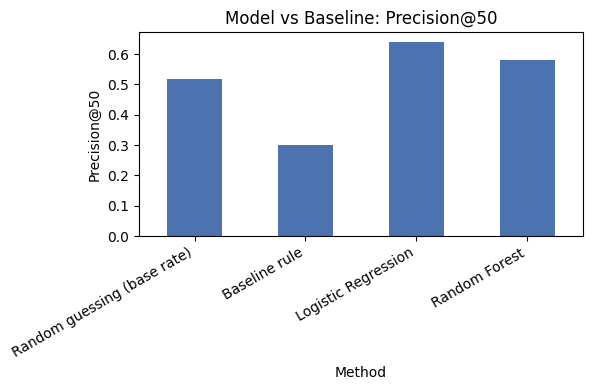

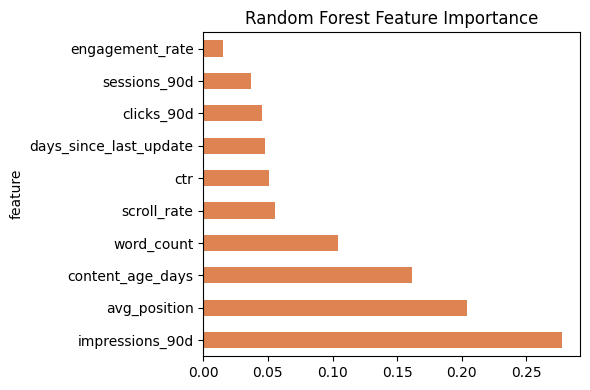

Saved charts, metrics.json, and action_queue.csv
{'precision_at_50_baseline': 0.3, 'precision_at_50_random_forest': 0.58, 'base_rate': 0.517, 'total_pages_ranked': 7115}


In [9]:
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('docs/img', exist_ok=True)

# Chart 1: model vs baseline
fig, ax = plt.subplots(figsize=(6,4))
comparison.set_index('Method')['Precision@50'].plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_ylabel('Precision@50')
ax.set_title('Model vs Baseline: Precision@50')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('docs/img/chart_precision_comparison.png', dpi=150)
plt.show()

# Chart 2: feature importance
fig, ax = plt.subplots(figsize=(6,4))
importances.set_index('feature')['importance'].plot(kind='barh', ax=ax, color='#DD8452')
ax.set_title('Random Forest Feature Importance')
plt.tight_layout()
plt.savefig('docs/img/chart_feature_importance.png', dpi=150)
plt.show()

# Save metrics (safe, no raw data) and action queue
import json
metrics_summary = {
    'precision_at_50_baseline': round(float(comparison.loc[1, 'Precision@50']), 3),
    'precision_at_50_random_forest': round(float(comparison.loc[3, 'Precision@50']), 3),
    'base_rate': round(float(base_rate), 3),
    'total_pages_ranked': len(action_queue),
}
with open('work/outputs/capstone_metrics.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

action_queue.to_csv('work/outputs/action_queue.csv', index=False)
print("Saved charts, metrics.json, and action_queue.csv")
print(metrics_summary)

## Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset. Data source: [FlyRank](https://flyrank.ai)

## Reproducibility

Full notebooks and code: [github.com/muhammadhuzaifanaeem/FlyRank-Internship](https://github.com/muhammadhuzaifanaeem/FlyRank-Internship)
All results use `random_state=42` for reproducibility.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.